# 06 — Stagnone di Marsala: In-Situ Data Processing & QC

This notebook loads, cleans, and visualizes the in-situ monitoring data for model calibration/validation.

**Water Level Stations (3):**
- BocaNord (BN): Northern inlet, 37.905°N 12.457°E — 3 min sampling
- BocaSud (BS): Southern inlet, 37.847°N 12.449°E — 1 min sampling
- AltavilaEst (AE): Internal lagoon, 37.890°N 12.447°E — 1 min sampling

**Wind Stations (2):**
- AltavilaEst (AE): 37.890°N 12.447°E — 10 min, 3m height
- Mulino: 37.868°N 12.482°E — 10 min, 3m height

**Period:** July 1-10, 2025 | **Timezone:** CET solar (UTC+1)

## 1. Imports and paths

In [1]:
%matplotlib inline
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

project_root = Path(r'F:\StagnoneDT')
insitu_dir = project_root / 'data' / 'raw' / 'insitu'
os.makedirs(insitu_dir, exist_ok=True)

# Station coordinates (WGS84)
stations = {
    'BocaNord': {'lat': 37.905, 'lon': 12.457, 'label': 'BN (northern inlet)'},
    'BocaSud':  {'lat': 37.847, 'lon': 12.449, 'label': 'BS (southern inlet)'},
    'AltavilaEst': {'lat': 37.890, 'lon': 12.447, 'label': 'AE (internal)'},
    'Mulino': {'lat': 37.868, 'lon': 12.482, 'label': 'Mulino (internal)'},
}

## 2. Load water level data

Three CSV files with different date formats and sampling rates.

In [3]:
# --- BocaNord (BN): 3-min sampling, format YYYY/M/D H:MM ---
bn = pd.read_csv(str(insitu_dir / 'boundaries_BN.csv'), encoding='utf-8-sig')
bn.columns = ['datetime_cet', 'wl_m']
bn['wl_m'] = pd.to_numeric(bn['wl_m'], errors='coerce')  # handles '[10]' and other bad values
bn['datetime_cet'] = pd.to_datetime(bn['datetime_cet'], format='mixed', dayfirst=False)
bn['datetime_utc'] = bn['datetime_cet'] - pd.Timedelta(hours=1)  # CET solar -> UTC
bn = bn.set_index('datetime_utc').sort_index()
print(f'BocaNord: {len(bn)} records, {bn.wl_m.isna().sum()} NaN, '
      f'range: {bn.wl_m.min():.3f} to {bn.wl_m.max():.3f} m')

# --- BocaSud (BS): 1-min sampling, format YYYY/M/D H:MM ---
bs = pd.read_csv(str(insitu_dir / 'boundaries_BS.csv'), encoding='utf-8-sig')
bs.columns = ['datetime_cet', 'wl_m']
bs['wl_m'] = pd.to_numeric(bs['wl_m'], errors='coerce')
bs['datetime_cet'] = pd.to_datetime(bs['datetime_cet'], format='mixed', dayfirst=False)
bs['datetime_utc'] = bs['datetime_cet'] - pd.Timedelta(hours=1)
bs = bs.set_index('datetime_utc').sort_index()
print(f'BocaSud:  {len(bs)} records, {bs.wl_m.isna().sum()} NaN, '
      f'range: {bs.wl_m.min():.3f} to {bs.wl_m.max():.3f} m')

# --- AltavilaEst (AE): 1-min sampling, format M/D/YYYY H:MM ---
ae = pd.read_csv(str(insitu_dir / 'boundaries_AE.csv'), encoding='utf-8-sig')
ae.columns = ['datetime_cet', 'wl_m']
ae['wl_m'] = pd.to_numeric(ae['wl_m'], errors='coerce')
ae['datetime_cet'] = pd.to_datetime(ae['datetime_cet'], format='mixed', dayfirst=False)
ae['datetime_utc'] = ae['datetime_cet'] - pd.Timedelta(hours=1)
ae = ae.set_index('datetime_utc').sort_index()
print(f'AltavEst: {len(ae)} records, {ae.wl_m.isna().sum()} NaN, '
      f'range: {ae.wl_m.min():.3f} to {ae.wl_m.max():.3f} m')

BocaNord: 4320 records, 2 NaN, range: -0.057 to 0.235 m
BocaSud:  12960 records, 0 NaN, range: -0.014 to 0.281 m
AltavEst: 12960 records, 1 NaN, range: -0.117 to 0.173 m


## 3. Load wind data

In [4]:
# --- AltavilaEst wind: 10-min, 3m height ---
wind_ae = pd.read_csv(str(insitu_dir / 'vento_AE.csv'), encoding='utf-8-sig')
wind_ae.columns = ['datetime_cet', 'dir_deg', 'speed_ms']
wind_ae['datetime_cet'] = pd.to_datetime(wind_ae['datetime_cet'], format='mixed', dayfirst=False)
wind_ae['datetime_utc'] = wind_ae['datetime_cet'] - pd.Timedelta(hours=1)
wind_ae = wind_ae.set_index('datetime_utc').sort_index()
wind_ae['speed_ms'] = pd.to_numeric(wind_ae['speed_ms'], errors='coerce')
wind_ae['dir_deg'] = pd.to_numeric(wind_ae['dir_deg'], errors='coerce')
print(f'Wind AE:  {len(wind_ae)} records, speed range: '
      f'{wind_ae.speed_ms.min():.1f} to {wind_ae.speed_ms.max():.1f} m/s (at 3m)')

# --- Mulino wind: 10-min, 3m height ---
wind_mul = pd.read_csv(str(insitu_dir / 'vento_Mul.csv'), encoding='utf-8-sig')
wind_mul.columns = ['datetime_cet', 'dir_deg', 'speed_ms']
wind_mul['datetime_cet'] = pd.to_datetime(wind_mul['datetime_cet'], format='mixed', dayfirst=False)
wind_mul['datetime_utc'] = wind_mul['datetime_cet'] - pd.Timedelta(hours=1)
wind_mul = wind_mul.set_index('datetime_utc').sort_index()
wind_mul['speed_ms'] = pd.to_numeric(wind_mul['speed_ms'], errors='coerce')
wind_mul['dir_deg'] = pd.to_numeric(wind_mul['dir_deg'], errors='coerce')
print(f'Wind Mul: {len(wind_mul)} records, speed range: '
      f'{wind_mul.speed_ms.min():.1f} to {wind_mul.speed_ms.max():.1f} m/s (at 3m)')

Wind AE:  1296 records, speed range: 0.0 to 9.2 m/s (at 3m)
Wind Mul: 1296 records, speed range: 0.0 to 11.1 m/s (at 3m)


In [5]:
# Convert wind speed from 3m to 10m using logarithmic wind profile
# u(z) = u(z_ref) * ln(z/z0) / ln(z_ref/z0)
# z0 ~ 0.001 for water surface (smooth)
z_meas = 3.0   # measurement height (m)
z_10 = 10.0     # target height (m)
z0 = 0.001      # roughness length for water

factor_3to10 = np.log(z_10 / z0) / np.log(z_meas / z0)
print(f'Wind speed correction factor (3m -> 10m): {factor_3to10:.3f}')

wind_ae['speed_10m'] = wind_ae['speed_ms'] * factor_3to10
wind_mul['speed_10m'] = wind_mul['speed_ms'] * factor_3to10

Wind speed correction factor (3m -> 10m): 1.150


## 4. Visualize water levels

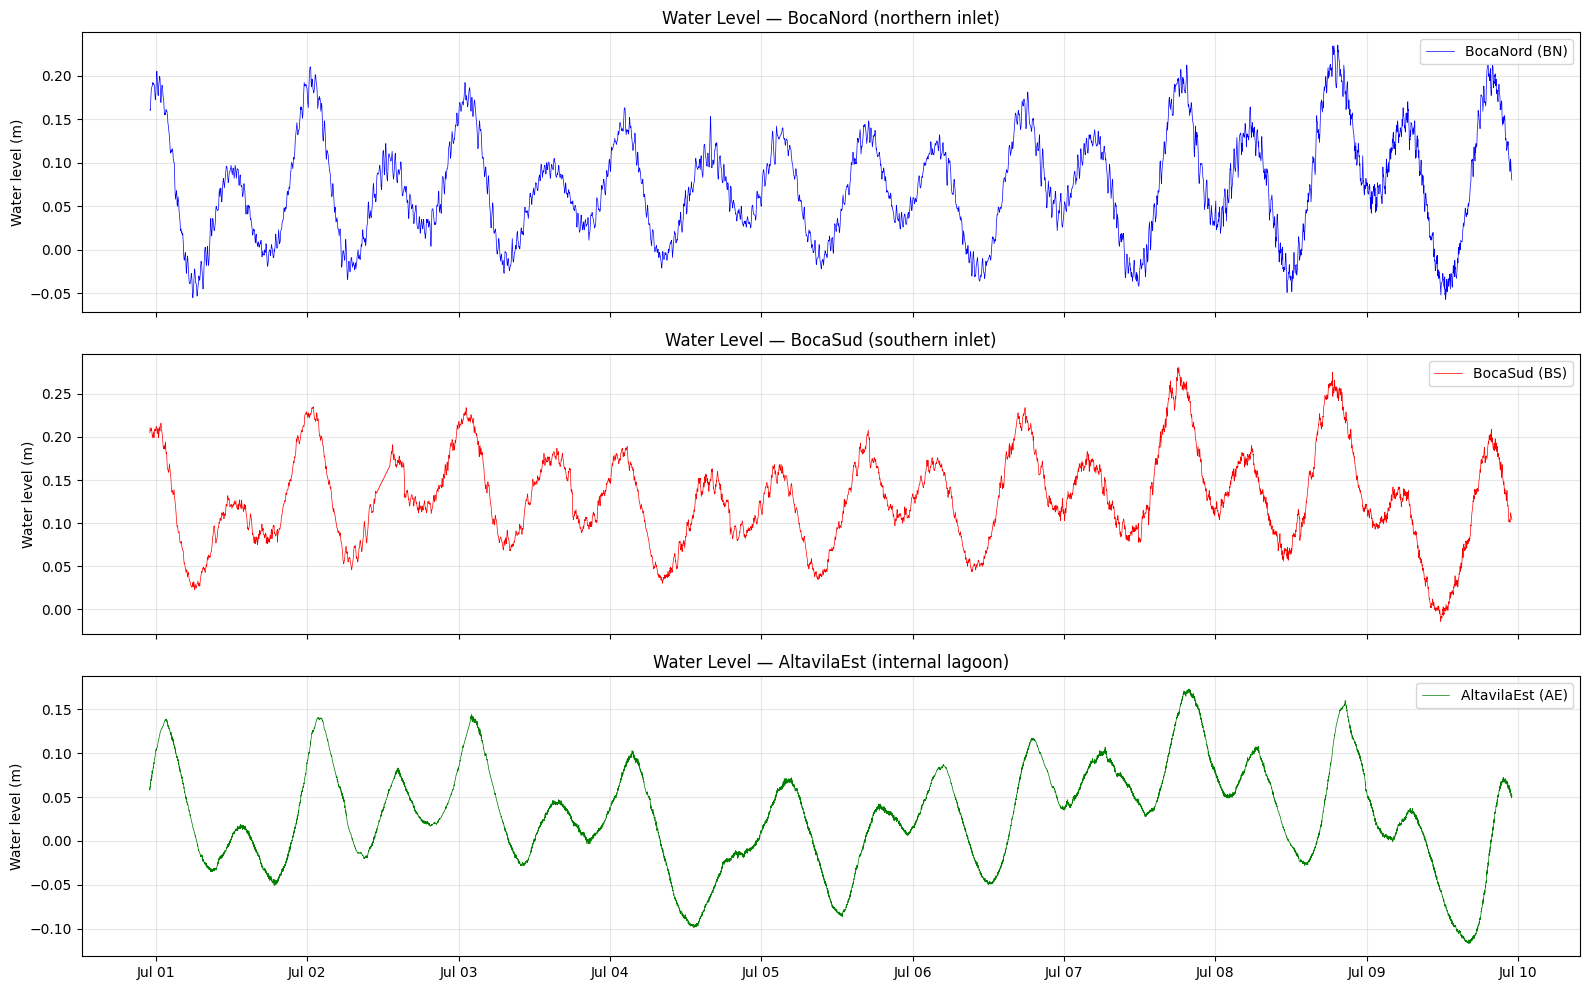

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# BocaNord
ax = axes[0]
ax.plot(bn.index, bn['wl_m'], 'b-', linewidth=0.5, label='BocaNord (BN)')
ax.set_ylabel('Water level (m)')
ax.set_title('Water Level — BocaNord (northern inlet)')
ax.legend()
ax.grid(True, alpha=0.3)

# BocaSud
ax = axes[1]
ax.plot(bs.index, bs['wl_m'], 'r-', linewidth=0.5, label='BocaSud (BS)')
ax.set_ylabel('Water level (m)')
ax.set_title('Water Level — BocaSud (southern inlet)')
ax.legend()
ax.grid(True, alpha=0.3)

# AltavilaEst
ax = axes[2]
ax.plot(ae.index, ae['wl_m'], 'g-', linewidth=0.5, label='AltavilaEst (AE)')
ax.set_ylabel('Water level (m)')
ax.set_title('Water Level — AltavilaEst (internal lagoon)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

fig.tight_layout()
plt.savefig(str(project_root / 'figures' / 'insitu_water_levels.png'), dpi=150, bbox_inches='tight')
plt.show()

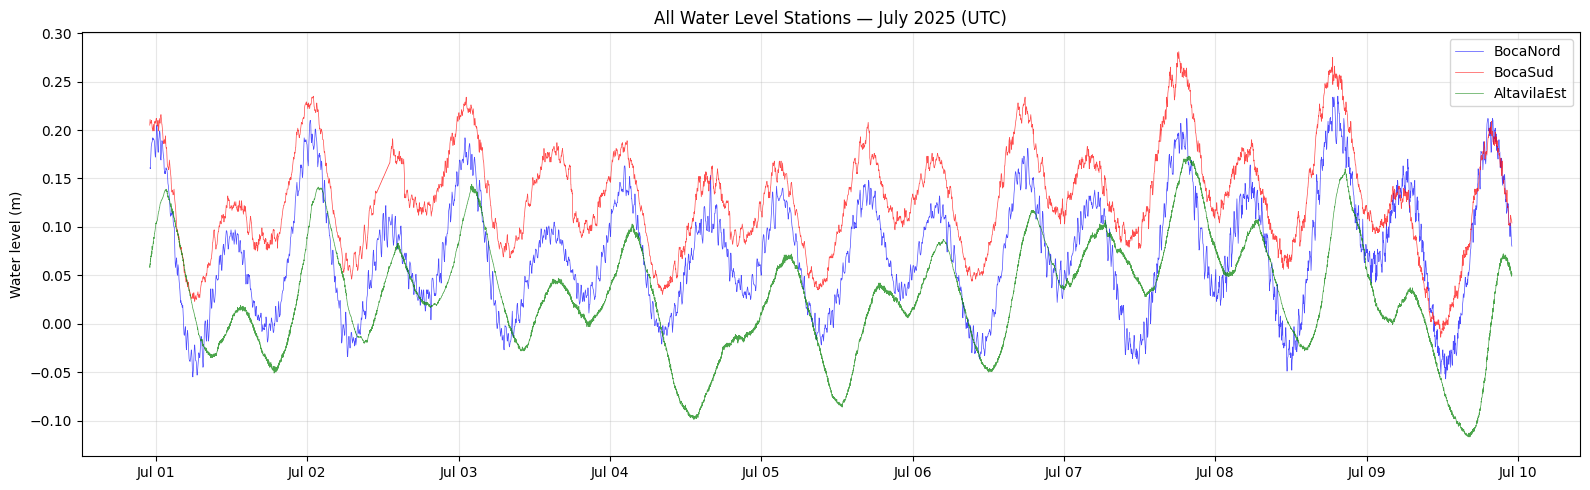


=== WATER LEVEL STATISTICS (m) ===
BocaNord       : mean=0.0732, std=0.0607, min=-0.057, max=0.235, range=0.292
BocaSud        : mean=0.1295, std=0.0538, min=-0.014, max=0.281, range=0.295
AltavilaEst    : mean=0.0298, std=0.0588, min=-0.117, max=0.173, range=0.290


In [7]:
# All stations overlaid
fig, ax = plt.subplots(figsize=(16, 5))

# Resample to 10-min for cleaner comparison
ax.plot(bn.index, bn['wl_m'], 'b-', linewidth=0.5, alpha=0.7, label='BocaNord')
ax.plot(bs.index, bs['wl_m'], 'r-', linewidth=0.5, alpha=0.7, label='BocaSud')
ax.plot(ae.index, ae['wl_m'], 'g-', linewidth=0.5, alpha=0.7, label='AltavilaEst')

ax.set_ylabel('Water level (m)')
ax.set_title('All Water Level Stations — July 2025 (UTC)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

fig.tight_layout()
plt.savefig(str(project_root / 'figures' / 'insitu_wl_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Basic statistics
print('\n=== WATER LEVEL STATISTICS (m) ===')
for name, df in [('BocaNord', bn), ('BocaSud', bs), ('AltavilaEst', ae)]:
    wl = df['wl_m'].dropna()
    print(f'{name:15s}: mean={wl.mean():.4f}, std={wl.std():.4f}, '
          f'min={wl.min():.3f}, max={wl.max():.3f}, range={wl.max()-wl.min():.3f}')

## 5. Visualize wind data

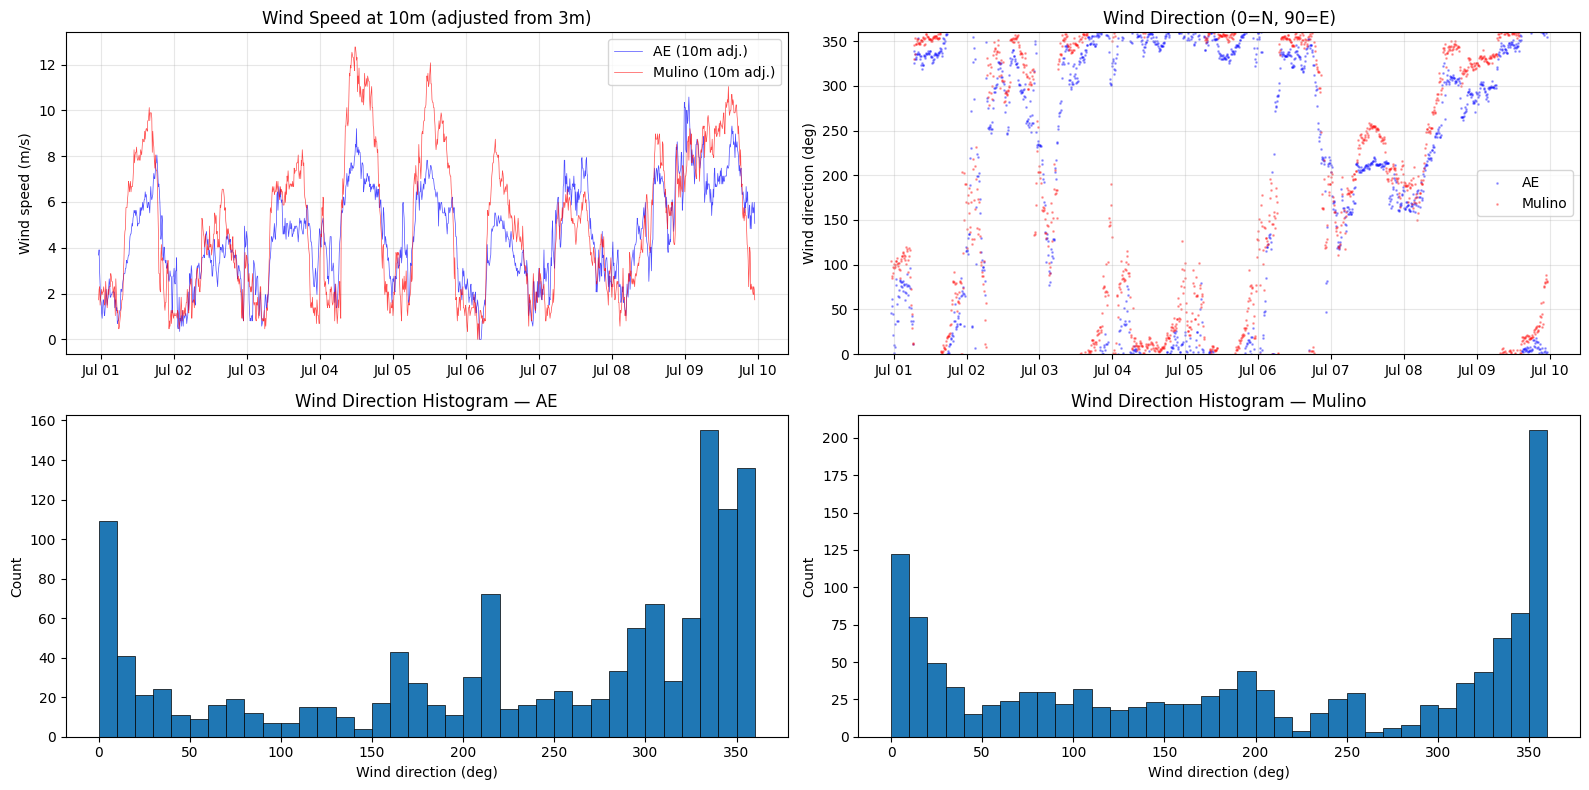


=== WIND STATISTICS (at 3m) ===
AE      : mean=3.9, max=9.2 m/s, calm (<0.5 m/s): 7 (0.5%)
Mulino  : mean=4.3, max=11.1 m/s, calm (<0.5 m/s): 7 (0.5%)


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Wind speed time series
ax = axes[0, 0]
ax.plot(wind_ae.index, wind_ae['speed_10m'], 'b-', linewidth=0.5, alpha=0.7, label='AE (10m adj.)')
ax.plot(wind_mul.index, wind_mul['speed_10m'], 'r-', linewidth=0.5, alpha=0.7, label='Mulino (10m adj.)')
ax.set_ylabel('Wind speed (m/s)')
ax.set_title('Wind Speed at 10m (adjusted from 3m)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Wind direction time series
ax = axes[0, 1]
ax.scatter(wind_ae.index, wind_ae['dir_deg'], c='blue', s=1, alpha=0.3, label='AE')
ax.scatter(wind_mul.index, wind_mul['dir_deg'], c='red', s=1, alpha=0.3, label='Mulino')
ax.set_ylabel('Wind direction (deg)')
ax.set_title('Wind Direction (0=N, 90=E)')
ax.set_ylim(0, 360)
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Wind roses (polar histograms)
for i, (name, wd) in enumerate([('AE', wind_ae), ('Mulino', wind_mul)]):
    ax = axes[1, i]
    valid = wd.dropna(subset=['dir_deg', 'speed_ms'])
    valid = valid[valid['speed_ms'] > 0.1]  # exclude calm
    ax.hist(valid['dir_deg'], bins=36, range=(0, 360), edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Wind direction (deg)')
    ax.set_ylabel('Count')
    ax.set_title(f'Wind Direction Histogram — {name}')

fig.tight_layout()
plt.savefig(str(project_root / 'figures' / 'insitu_wind.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n=== WIND STATISTICS (at 3m) ===')
for name, df in [('AE', wind_ae), ('Mulino', wind_mul)]:
    s = df['speed_ms'].dropna()
    print(f'{name:8s}: mean={s.mean():.1f}, max={s.max():.1f} m/s, '
          f'calm (<0.5 m/s): {(s < 0.5).sum()} ({(s < 0.5).mean()*100:.1f}%)')

## 6. Compare wind with ERA5

Load ERA5 wind from the model forcing and compare with in-situ.

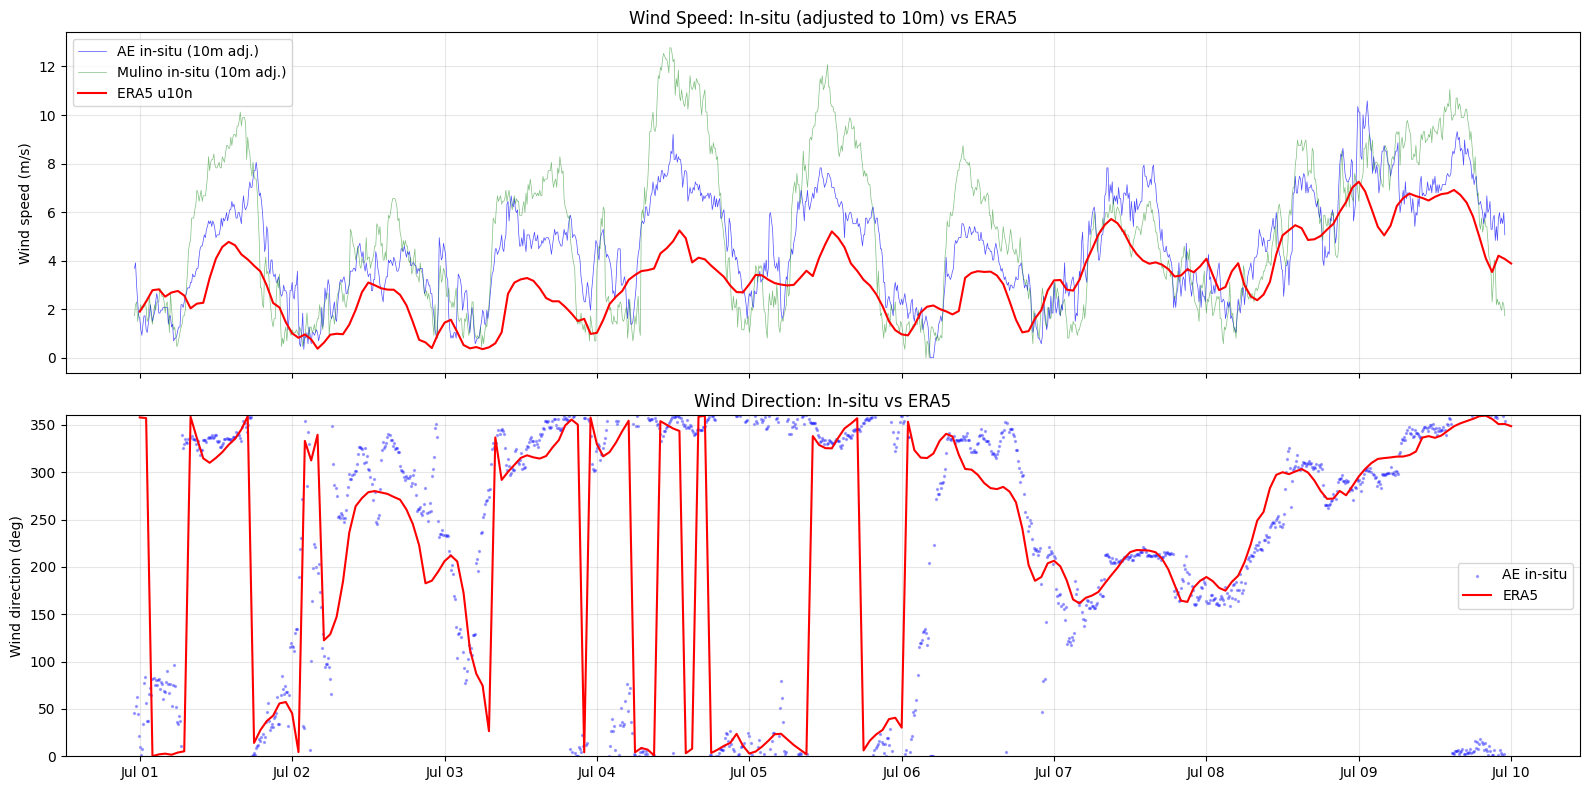

In [9]:
import xarray as xr

model_dir = project_root / 'model' / 'dflowfm'
era5_u = xr.open_dataset(str(model_dir / 'era5_u10n_20250701to20250710_ERA5.nc'))
era5_v = xr.open_dataset(str(model_dir / 'era5_v10n_20250701to20250710_ERA5.nc'))

# Extract ERA5 at nearest grid point to AE station
ae_lat, ae_lon = 37.890, 12.447
u_ae = era5_u['u10n'].sel(latitude=ae_lat, longitude=ae_lon, method='nearest')
v_ae = era5_v['v10n'].sel(latitude=ae_lat, longitude=ae_lon, method='nearest')
era5_speed = np.sqrt(u_ae**2 + v_ae**2)
era5_dir = (270 - np.degrees(np.arctan2(v_ae, u_ae))) % 360  # meteorological convention

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax = axes[0]
ax.plot(wind_ae.index, wind_ae['speed_10m'], 'b-', linewidth=0.5, alpha=0.7, label='AE in-situ (10m adj.)')
ax.plot(wind_mul.index, wind_mul['speed_10m'], 'g-', linewidth=0.5, alpha=0.5, label='Mulino in-situ (10m adj.)')
ax.plot(era5_speed.time, era5_speed, 'r-', linewidth=1.5, label='ERA5 u10n')
ax.set_ylabel('Wind speed (m/s)')
ax.set_title('Wind Speed: In-situ (adjusted to 10m) vs ERA5')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(wind_ae.index, wind_ae['dir_deg'], c='blue', s=2, alpha=0.3, label='AE in-situ')
ax.plot(era5_dir.time, era5_dir, 'r-', linewidth=1.5, label='ERA5')
ax.set_ylabel('Wind direction (deg)')
ax.set_title('Wind Direction: In-situ vs ERA5')
ax.set_ylim(0, 360)
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

fig.tight_layout()
plt.savefig(str(project_root / 'figures' / 'insitu_vs_era5_wind.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Save processed data for calibration

Resample all stations to 10-min and save as clean CSV.

In [10]:
# Resample water levels to 10-min
bn_10min = bn['wl_m'].resample('10min').mean().dropna()
bs_10min = bs['wl_m'].resample('10min').mean().dropna()
ae_10min = ae['wl_m'].resample('10min').mean().dropna()

# Save
processed_dir = project_root / 'data' / 'processed'
os.makedirs(processed_dir, exist_ok=True)

bn_10min.to_csv(str(processed_dir / 'wl_BocaNord_10min_UTC.csv'), header=['wl_m'])
bs_10min.to_csv(str(processed_dir / 'wl_BocaSud_10min_UTC.csv'), header=['wl_m'])
ae_10min.to_csv(str(processed_dir / 'wl_AltavilaEst_10min_UTC.csv'), header=['wl_m'])
wind_ae.to_csv(str(processed_dir / 'wind_AE_10min_UTC.csv'))
wind_mul.to_csv(str(processed_dir / 'wind_Mulino_10min_UTC.csv'))

print('Processed files saved to:', processed_dir)
print(f'  BN: {len(bn_10min)} records')
print(f'  BS: {len(bs_10min)} records')
print(f'  AE: {len(ae_10min)} records')
print(f'  Wind AE: {len(wind_ae)} records')
print(f'  Wind Mulino: {len(wind_mul)} records')

Processed files saved to: F:\StagnoneDT\data\processed
  BN: 1297 records
  BS: 1297 records
  AE: 1297 records
  Wind AE: 1296 records
  Wind Mulino: 1296 records


## 8. Key observations

### Water levels
- BocaNord shows higher variability (direct exposure to sea) than BocaSud
- AltavilaEst (internal) shows damped signal compared to the inlets
- Tidal range is very small (~0.2-0.3m), confirming microtidal regime
- Wind setup/setdown events are visible as asymmetric water level changes

### Wind
- Measurements at 3m → adjusted to 10m using log profile (factor ~1.18)
- Comparison with ERA5 will reveal systematic bias
- Dominant wind directions should be checked against typical NW (Maestrale) and SE (Scirocco) patterns

### For model calibration
- All data converted to UTC and resampled to 10-min (matching model HisInterval)
- Model output at BocaNord, BocaSud, AltavilaEst observation points can be directly compared